## 智能体通信协议

MCP

A2A

ANP

用React框架可以使LLM更好地借助工具完成工作，但它面临着三个根本性的限制。

> 首先是工具集成的困境：每当需要访问新的外部服务（如 GitHub API、数据库、文件系统），我们都必须编写专门的 Tool 类。这不仅工作量大，而且不同开发者编写的工具无法互相兼容。

> 其次是能力扩展的瓶颈：智能体的能力被限制在预先定义的工具集内，无法动态发现和使用新的服务。

> 最后是协作的缺失：当任务复杂到需要多个专业智能体协作时（如研究员+撰写员+编辑），我们只能通过手动编排来协调它们的工作。

通信协议的核心价值正是解决这些问题。它提供了一套标准化的接口规范，让智能体能够以统一的方式访问各种外部服务，而无需为每个服务编写专门的适配器。这就像互联网的 TCP/IP 协议，它让不同的设备能够相互通信，而不需要为每种设备编写专门的通信代码。

通信协议带来的改变是根本性的：标准化接口让不同服务提供统一的访问方式，互操作性使得不同开发者的工具可以无缝集成，动态发现允许智能体在运行时发现新的服务和能力，可扩展性让系统能够轻松添加新的功能模块。

In [ ]:
# 传统方式：手动集成每个服务
class GitHubTool(BaseTool):
    """需要手写GitHub API适配器"""
    def run(self, repo_url):
        # 大量的API调用代码...
        pass

class DatabaseTool(BaseTool):
    """需要手写数据库适配器"""
    def run(self, query):
        # 数据库连接和查询代码...
        pass

class WeatherTool(BaseTool):
    """需要手写天气API适配器"""
    def run(self, location):
        # 天气API调用代码...
        pass

# 每个新服务都需要重复这个过程
agent.add_tool(GitHubTool())
agent.add_tool(DatabaseTool())
agent.add_tool(WeatherTool())

# MCP写法
from hello_agents.tools import MCPTool

# 连接到MCP服务器，自动获得所有工具
mcp_tool = MCPTool()  # 内置服务器提供基础工具

# 或者连接到专业的MCP服务器
github_mcp = MCPTool(server_command=["npx", "-y", "@modelcontextprotocol/server-github"])
database_mcp = MCPTool(server_command=["python", "database_mcp_server.py"])

# 智能体自动获得所有能力，无需手写适配器
agent.add_tool(mcp_tool)
agent.add_tool(github_mcp)
agent.add_tool(database_mcp)


## MCP：智能体与工具的桥梁

MCP（Model Context Protocol）由 Anthropic 团队提出[1]，其核心设计理念是标准化智能体与外部工具/资源的通信方式。想象一下，你的智能体需要访问文件系统、数据库、GitHub、Slack 等各种服务。传统做法是为每个服务编写专门的适配器，这不仅工作量大，而且难以维护。MCP 通过定义统一的协议规范，让所有服务都能以相同的方式被访问。

MCP 的设计哲学是"上下文共享"。它不仅仅是一个 RPC（远程过程调用）协议，更重要的是它允许智能体和工具之间共享丰富的上下文信息。如图 10.1 所示，当智能体访问一个代码仓库时，MCP 服务器不仅能提供文件内容，还能提供代码结构、依赖关系、提交历史等上下文信息，让智能体能够做出更智能的决策。

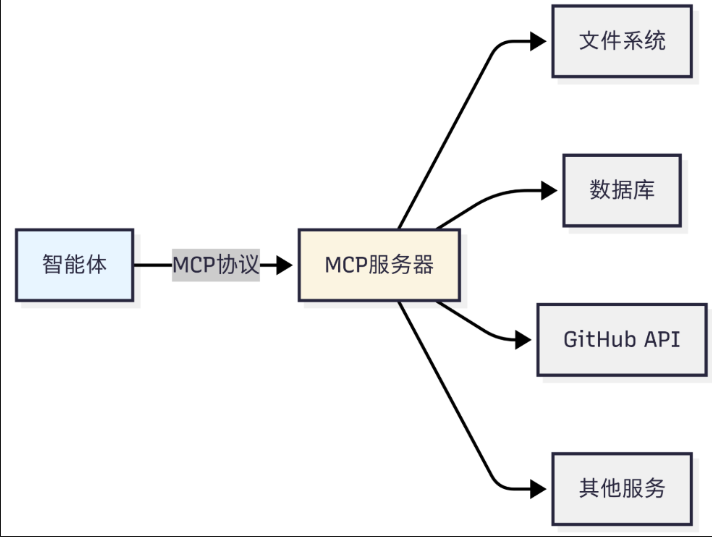

#### MCP架构：
MCP 协议采用 Host、Client、Servers 三层架构设计

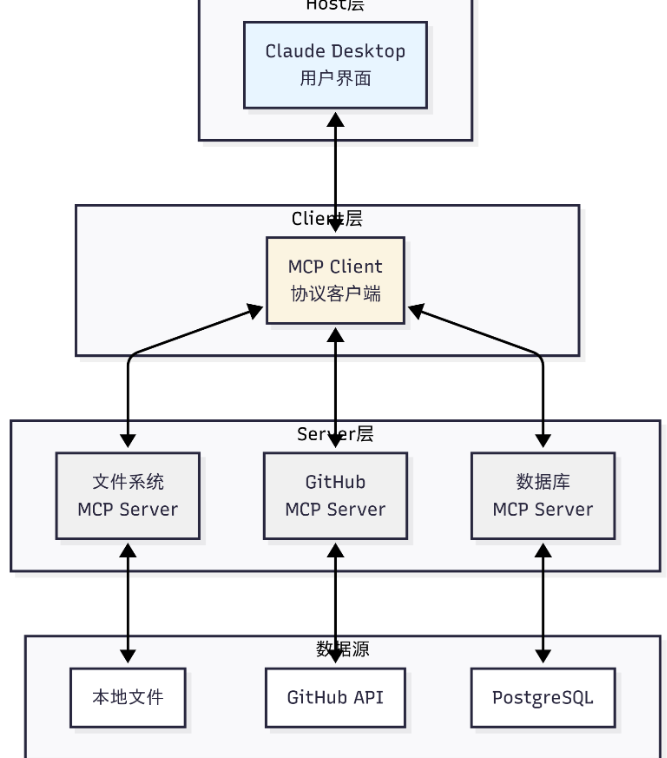

三层架构的职责：

* Host（宿主层）：Claude Desktop 作为 Host，负责接收用户提问并与 Claude 模型交互。Host 是用户直接交互的界面，它管理整个对话流程。

* Client（客户端层）：当 Claude 模型决定需要访问文件系统时，Host 中内置的 MCP Client 被激活。Client 负责与适当的 MCP Server 建立连接，发送请求并接收响应。

* Server（服务器层）：文件系统 MCP Server 被调用，执行实际的文件扫描操作，访问桌面目录，并返回找到的文档列表。

完整的交互流程：用户问题 → Claude Desktop(Host) → Claude 模型分析 → 需要文件信息 → MCP Client 连接 → 文件系统 MCP Server → 执行操作 → 返回结果 → Claude 生成回答 → 显示在 Claude Desktop 上

MCP 的核心能力：Tools 是主动的（执行操作），Resources 是被动的（提供数据），Prompts 是指导性的（提供模板）

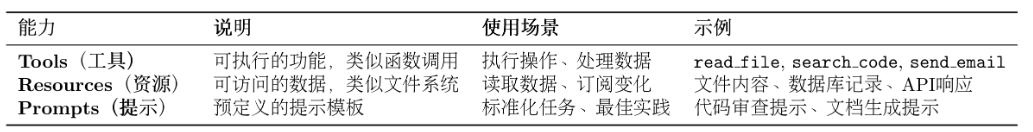

MCP 的工作流程：

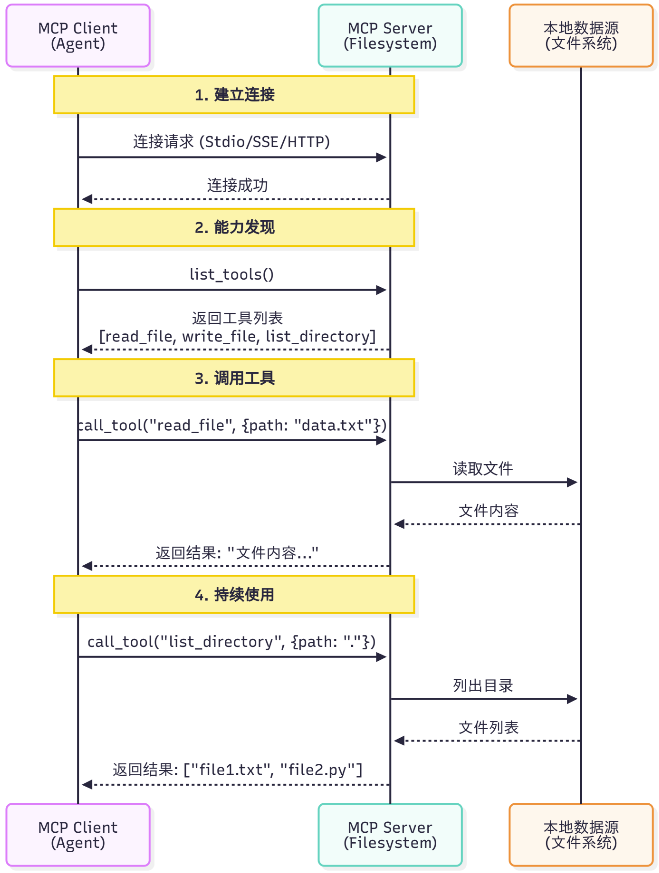

完整的工具选择流程如下：

* 工具发现阶段：MCP Client 连接到 Server 后，首先调用list_tools()获取所有可用工具的描述信息（包括工具名称、功能说明、参数定义）

* 上下文构建：Client 将工具列表转换为 LLM 能理解的格式，添加到系统提示词中。例如：

    你可以使用以下工具：
    - read_file(path: str): 读取指定路径的文件内容
    - search_code(query: str, language: str): 在代码库中搜索
    Copy to clipboardErrorCopied
    模型推理：LLM 分析用户问题和可用工具，决定是否需要调用工具以及调用哪个工具。这个决策基于工具的描述和当前对话上下文

* 工具执行：如果 LLM 决定使用工具，Client 通过 MCP Server 执行所选工具，获取结果

* 结果整合：工具执行结果被送回给 LLM，LLM 结合结果生成最终回答

这个过程是完全自动化的，LLM 会根据工具描述的质量来决定是否使用以及如何使用工具。因此，编写清晰、准确的工具描述至关重要。

In [ ]:
async def discover_tools():
    client = MCPClient(["npx", "-y", "@modelcontextprotocol/server-filesystem", "."])

    async with client:
        # 获取所有可用工具
        tools = await client.list_tools()

        print(f"服务器提供了 {len(tools)} 个工具：")
        for tool in tools:
            print(f"\n工具名称: {tool['name']}")
            print(f"描述: {tool.get('description', '无描述')}")

            # 打印参数信息
            if 'inputSchema' in tool:
                schema = tool['inputSchema']
                if 'properties' in schema:
                    print("参数:")
                    for param_name, param_info in schema['properties'].items():
                        param_type = param_info.get('type', 'any')
                        param_desc = param_info.get('description', '')
                        print(f"  - {param_name} ({param_type}): {param_desc}")

asyncio.run(discover_tools())

# 输出示例：
# 服务器提供了 5 个工具：
#
# 工具名称: read_file
# 描述: 读取文件内容
# 参数:
#   - path (string): 文件路径
#
# 工具名称: write_file
# 描述: 写入文件内容
# 参数:
#   - path (string): 文件路径
#   - content (string): 文件内容


In [ ]:
async def use_tools():
    client = MCPClient(["npx", "-y", "@modelcontextprotocol/server-filesystem", "."])

    async with client:
        # 读取文件
        result = await client.call_tool("read_file", {"path": "my_README.md"})
        print(f"文件内容：\n{result}")

        # 列出目录
        result = await client.call_tool("list_directory", {"path": "."})
        print(f"当前目录文件：{result}")

        # 写入文件
        result = await client.call_tool("write_file", {
            "path": "output.txt",
            "content": "Hello from MCP!"
        })
        print(f"写入结果：{result}")

asyncio.run(use_tools())


In [ ]:
# 列出可用资源
resources = client.list_resources()
print(f"可用资源：{[r['uri'] for r in resources]}")

# 读取资源
resource_content = client.read_resource("file:///path/to/resource")
print(f"资源内容：{resource_content}")


# 列出可用提示
prompts = client.list_prompts()
print(f"可用提示：{[p['name'] for p in prompts]}")

# 获取提示内容
prompt = client.get_prompt("code_review", {"language": "python"})
print(f"提示内容：{prompt}")


除了工具，MCP还可以提供一些供智能体阅读的资源

以及预定义的提示词模板

### MCP传输方式

MCP传输主要指的是MCP客户端（MCP_tool或者是MCP_Client）和MCP服务器之间的信息传输

MCP 协议的一个重要特性是传输层无关性（Transport Agnostic）。这意味着 MCP 协议本身不依赖于特定的传输方式，可以在不同的通信通道上运行。

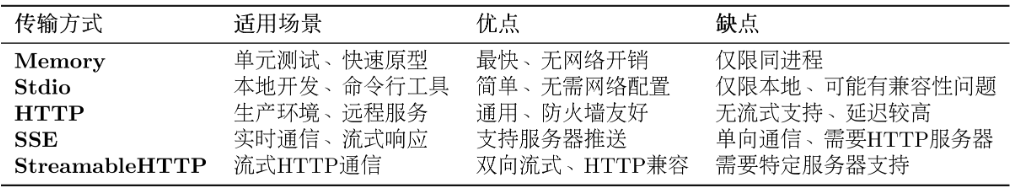


### 智能体使用MCP
将MCP中的工具展开

具体原理：

    # 用户代码
    fs_tool = MCPTool(name="fs", server_command=[...])
    agent.add_tool(fs_tool)

    # 内部发生的事情：
    # 1. MCPTool连接到服务器，发现14个工具
    # 2. 为每个工具创建包装器：
    #    - fs_read_text_file (参数: path, tail, head)
    #    - fs_write_file (参数: path, content)
    #    - ...
    # 3. 注册到Agent的工具注册表

    # Agent调用
    response = agent.run("读取README.md")

    # Agent内部：
    # 1. 识别需要调用 fs_read_text_file
    # 2. 生成参数：path=README.md
    # 3. 包装器转换为MCP格式：
    #    {"action": "call_tool", "tool_name": "read_text_file", "arguments": {"path": "README.md"}}
    # 4. 调用MCP服务器
    # 5. 返回文件内容

In [ ]:
from hello_agents.tools import MCPTool

# 1. Memory Transport - 内存传输（用于测试）
# 不指定任何参数，使用内置演示服务器
mcp_tool = MCPTool()

# 2. Stdio Transport - 标准输入输出传输（本地开发）
# 使用命令列表启动本地服务器
mcp_tool = MCPTool(server_command=["python", "examples/mcp_example_server.py"])

# 3. Stdio Transport with Args - 带参数的命令传输
# 可以传递额外参数
mcp_tool = MCPTool(server_command=["python", "examples/mcp_example_server.py", "--debug"])

# 4. Stdio Transport - 社区服务器（npx方式）
# 使用npx启动社区MCP服务器
mcp_tool = MCPTool(server_command=["npx", "-y", "@modelcontextprotocol/server-filesystem", "."])

# 5. HTTP/SSE/StreamableHTTP Transport
# 注意：MCPTool主要用于Stdio和Memory传输
# 对于HTTP/SSE等远程传输，建议直接使用MCPClient


## A2A：智能体间的对话

A2A（Agent-to-Agent Protocol）协议由 Google 团队提出2，其核心设计理念是实现智能体之间的点对点通信。与 MCP 关注智能体与工具的通信不同，A2A 关注的是智能体之间如何相互协作。这种设计让智能体能够像人类团队一样进行对话、协商和协作。

A2A 的设计哲学是"对等通信"。如图 10.2 所示，在 A2A 网络中，每个智能体既是服务提供者，也是服务消费者。智能体可以主动发起请求，也可以响应其他智能体的请求。这种对等的设计避免了中心化协调器的瓶颈，让智能体网络更加灵活和可扩展。

传统的中央协调器（星型拓扑）方案存在三个主要问题：

* 单点故障：协调器失效导致系统整体瘫痪。
* 性能瓶颈：所有通信都经过中心节点，限制了并发。
* 扩展困难：增加或修改智能体需要改动中心逻辑。

#### 核心概念：

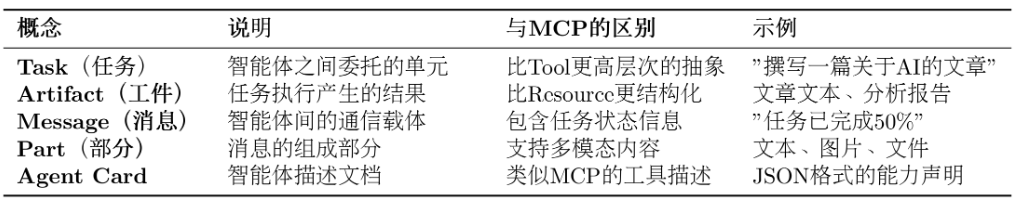

为实现对协作过程的管理，A2A 为任务定义了标准化的生命周期，包括创建、协商、代理、执行中、完成、失败等状态。该机制使智能体可以进行任务协商、进度跟踪和异常处理：

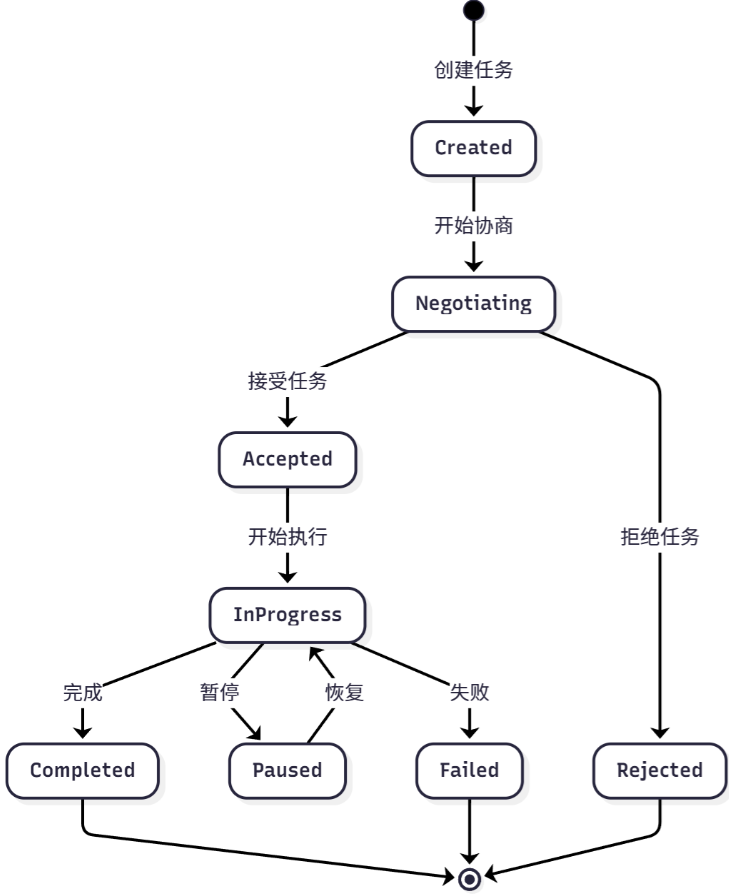

A2A 请求生命周期是一个序列，详细说明了请求遵循的四个主要步骤：代理发现、身份验证、发送消息 API 和发送消息流 API。

## ANP：智能体网络的基础设施

ANP（Agent Network Protocol）是一个概念性的协议框架，目前由开源社区维护，还没有成熟的生态，其核心设计理念是构建大规模智能体网络的基础设施。如果说 MCP 解决的是"如何访问工具"，A2A 解决的是"如何与其他智能体对话"，那么 ANP 解决的是"如何在大规模网络中发现和连接智能体"。

ANP 的设计哲学是"去中心化服务发现"。在一个包含成百上千个智能体的网络中，如何让智能体能够找到它需要的服务？如图 10.3 所示，ANP 提供了服务注册、发现和路由机制，让智能体能够动态地发现网络中的其他服务，而不需要预先配置所有的连接关系。

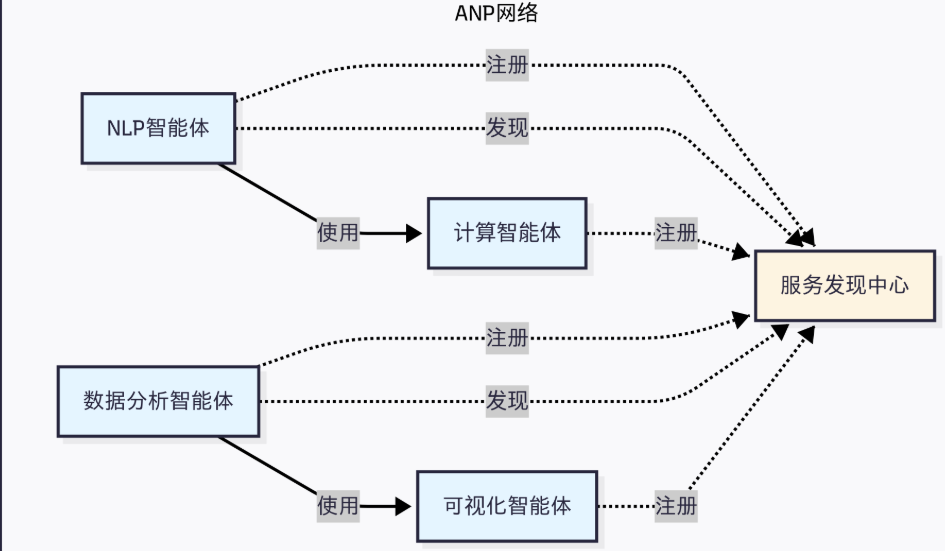